In [16]:
# If running in Google Colab, uncomment this:
# !pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
Num GPUs Available: 0


In [17]:
DATASET_DIR = r"E:\Pyhton code\Data Sets\archive\skin cancer"

In [18]:
IMAGE_DIR = os.path.join(DATASET_DIR, "images")
MASK_DIR = os.path.join(DATASET_DIR, "masks")
CSV_PATH = os.path.join(DATASET_DIR, "GroundTruth.csv")

print("Dataset directory:", DATASET_DIR)
print("Image directory:", IMAGE_DIR)
print("Mask directory:", MASK_DIR)
print("CSV:", CSV_PATH)

print("\nExists?")
print("Dataset:", os.path.exists(DATASET_DIR))
print("Images:", os.path.exists(IMAGE_DIR))
print("Masks:", os.path.exists(MASK_DIR))
print("CSV:", os.path.exists(CSV_PATH))

Dataset directory: E:\Pyhton code\Data Sets\archive\skin cancer
Image directory: E:\Pyhton code\Data Sets\archive\skin cancer\images
Mask directory: E:\Pyhton code\Data Sets\archive\skin cancer\masks
CSV: E:\Pyhton code\Data Sets\archive\skin cancer\GroundTruth.csv

Exists?
Dataset: True
Images: True
Masks: True
CSV: True


In [19]:
# inspect files
print("Files in dataset root:")
for item in os.listdir(DATASET_DIR):
    print(" -", item)

print("\nNumber of image files:")

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.JPG", "*.JPEG", "*.PNG"]

image_files = []

for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(IMAGE_DIR, ext)))

print(len(image_files))

print("\nFirst 10 images:")
for f in image_files[:10]:
    print(os.path.basename(f))

Files in dataset root:
 - GroundTruth.csv
 - images
 - masks

Number of image files:
20030

First 10 images:
ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg
ISIC_0024311.jpg
ISIC_0024312.jpg
ISIC_0024313.jpg
ISIC_0024314.jpg
ISIC_0024315.jpg


In [20]:
# load ground truth csv
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

Shape: (10015, 8)

Columns:
['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

First 5 rows:


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0



Data types:
image     object
MEL      float64
NV       float64
BCC      float64
AKIEC    float64
BKL      float64
DF       float64
VASC     float64
dtype: object


In [21]:
# inspect csv more deeply
print("Number of rows:", len(df))

print("\nMissing values:")
display(df.isnull().sum())

print("\nUnique values per column:")

for column in df.columns:
    print(f"\n{column}:")
    print("Number of unique:", df[column].nunique())
    print("Sample:", df[column].dropna().unique()[:20])

Number of rows: 10015

Missing values:


image    0
MEL      0
NV       0
BCC      0
AKIEC    0
BKL      0
DF       0
VASC     0
dtype: int64


Unique values per column:

image:
Number of unique: 10015
Sample: ['ISIC_0024306' 'ISIC_0024307' 'ISIC_0024308' 'ISIC_0024309'
 'ISIC_0024310' 'ISIC_0024311' 'ISIC_0024312' 'ISIC_0024313'
 'ISIC_0024314' 'ISIC_0024315' 'ISIC_0024316' 'ISIC_0024317'
 'ISIC_0024318' 'ISIC_0024319' 'ISIC_0024320' 'ISIC_0024321'
 'ISIC_0024322' 'ISIC_0024323' 'ISIC_0024324' 'ISIC_0024325']

MEL:
Number of unique: 2
Sample: [0. 1.]

NV:
Number of unique: 2
Sample: [1. 0.]

BCC:
Number of unique: 2
Sample: [0. 1.]

AKIEC:
Number of unique: 2
Sample: [0. 1.]

BKL:
Number of unique: 2
Sample: [0. 1.]

DF:
Number of unique: 2
Sample: [0. 1.]

VASC:
Number of unique: 2
Sample: [0. 1.]


In [22]:
# determine the label stucture
for column in df.columns:
    print("\n" + "=" * 60)
    print("COLUMN:", column)
    print("=" * 60)
    
    if df[column].dtype == "object":
        print(df[column].value_counts().head(20))
    else:
        print(df[column].describe())


COLUMN: image
image
ISIC_0034320    1
ISIC_0024306    1
ISIC_0024307    1
ISIC_0024308    1
ISIC_0024309    1
ISIC_0024310    1
ISIC_0024311    1
ISIC_0024312    1
ISIC_0024313    1
ISIC_0024314    1
ISIC_0024315    1
ISIC_0024316    1
ISIC_0024317    1
ISIC_0024318    1
ISIC_0024319    1
ISIC_0034304    1
ISIC_0034303    1
ISIC_0034302    1
ISIC_0034301    1
ISIC_0034300    1
Name: count, dtype: int64

COLUMN: MEL
count    10015.000000
mean         0.111133
std          0.314313
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: MEL, dtype: float64

COLUMN: NV
count    10015.000000
mean         0.669496
std          0.470418
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: NV, dtype: float64

COLUMN: BCC
count    10015.000000
mean         0.051323
std          0.220667
min          0.000000
25%          0.000000
50%          0.000000
75%          0.00000

In [23]:
#Automatically idenitfy possible image ID column
possible_id_columns = []

for col in df.columns:
    col_lower = col.lower()
    
    if any(keyword in col_lower for keyword in [
        "image", "image_id", "img", "filename", "file", "id"
    ]):
        possible_id_columns.append(col)

print("Possible image ID columns:")
print(possible_id_columns)

Possible image ID columns:
['image']


In [24]:
# inspect actual filenames vs csv
print("Example image filenames:")

for f in image_files[:20]:
    print(os.path.basename(f))

print("\nExample CSV values from possible ID columns:")

for col in possible_id_columns:
    print("\nCOLUMN:", col)
    print(df[col].head(10).tolist())

Example image filenames:
ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg
ISIC_0024311.jpg
ISIC_0024312.jpg
ISIC_0024313.jpg
ISIC_0024314.jpg
ISIC_0024315.jpg
ISIC_0024316.jpg
ISIC_0024317.jpg
ISIC_0024318.jpg
ISIC_0024319.jpg
ISIC_0024320.jpg
ISIC_0024321.jpg
ISIC_0024322.jpg
ISIC_0024323.jpg
ISIC_0024324.jpg
ISIC_0024325.jpg

Example CSV values from possible ID columns:

COLUMN: image
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']


In [25]:
# create image lookup
image_lookup = {}

for f in image_files:
    filename = os.path.basename(f)
    stem = os.path.splitext(filename)[0]
    image_lookup[stem] = f

print("Images indexed:", len(image_lookup))

print("\nExample:")
for key, value in list(image_lookup.items())[:5]:
    print(key, "->", value)

Images indexed: 10015

Example:
ISIC_0024306 -> E:\Pyhton code\Data Sets\archive\skin cancer\images\ISIC_0024306.jpg
ISIC_0024307 -> E:\Pyhton code\Data Sets\archive\skin cancer\images\ISIC_0024307.jpg
ISIC_0024308 -> E:\Pyhton code\Data Sets\archive\skin cancer\images\ISIC_0024308.jpg
ISIC_0024309 -> E:\Pyhton code\Data Sets\archive\skin cancer\images\ISIC_0024309.jpg
ISIC_0024310 -> E:\Pyhton code\Data Sets\archive\skin cancer\images\ISIC_0024310.jpg


In [26]:
# Identify ID column automatically
id_column = None

# First, look for common names
preferred_names = [
    "image_id",
    "image",
    "imageid",
    "filename",
    "file",
    "id"
]

for name in preferred_names:
    matching = [c for c in df.columns if c.lower() == name]
    if matching:
        id_column = matching[0]
        break

# If not found, try matching columns against image filenames
if id_column is None:
    best_column = None
    best_matches = 0
    
    for col in df.columns:
        matches = 0
        
        for value in df[col].astype(str):
            value_stem = os.path.splitext(os.path.basename(value))[0]
            
            if value_stem in image_lookup:
                matches += 1
        
        if matches > best_matches:
            best_matches = matches
            best_column = col
    
    if best_matches > 0:
        id_column = best_column

print("Detected ID column:", id_column)

Detected ID column: image


In [27]:
# check id matching
if id_column is None:
    raise ValueError(
        "Could not automatically identify the image ID column. "
        "Please inspect Cell 6 and Cell 8 output."
    )

df["_image_stem"] = (
    df[id_column]
    .astype(str)
    .apply(lambda x: os.path.splitext(os.path.basename(x))[0])
)

df["image_path"] = df["_image_stem"].map(image_lookup)

print("CSV rows:", len(df))
print("Rows with matching images:", df["image_path"].notna().sum())
print("Rows without matching images:", df["image_path"].isna().sum())

display(df[[id_column, "_image_stem", "image_path"]].head())

CSV rows: 10015
Rows with matching images: 10015
Rows without matching images: 0


,image,_image_stem,image_path
0,ISIC_0024306,ISIC_0024306,E:\Pyhton code\Data Sets\archive\skin cancer\i...
1,ISIC_0024307,ISIC_0024307,E:\Pyhton code\Data Sets\archive\skin cancer\i...
2,ISIC_0024308,ISIC_0024308,E:\Pyhton code\Data Sets\archive\skin cancer\i...
3,ISIC_0024309,ISIC_0024309,E:\Pyhton code\Data Sets\archive\skin cancer\i...
4,ISIC_0024310,ISIC_0024310,E:\Pyhton code\Data Sets\archive\skin cancer\i...


In [28]:
# remove rows without images
df = df[df["image_path"].notna()].copy()

df.reset_index(drop=True, inplace=True)

print("Dataset after image matching:", df.shape)

Dataset after image matching: (10015, 10)


In [29]:
# detect target/label columns
print("All columns:")
print(df.columns.tolist())

All columns:
['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC', '_image_stem', 'image_path']


In [31]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [32]:
# automatically detect one-hot diagnosis columns
candidate_label_columns = []

for col in numeric_columns:
    if col in ["_image_stem"]:
        continue
    
    unique_values = set(df[col].dropna().unique())
    
    # One-hot columns normally contain only 0/1
    if unique_values.issubset({0, 1}):
        candidate_label_columns.append(col)

print("Possible one-hot label columns:")
print(candidate_label_columns)

Possible one-hot label columns:
['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [33]:
# create diagnosis label
if len(candidate_label_columns) >= 2:
    
    df["label"] = df[candidate_label_columns].idxmax(axis=1)
    
    # Check whether any row has no positive label
    label_sum = df[candidate_label_columns].sum(axis=1)
    
    print("Rows with exactly one diagnosis:")
    print((label_sum == 1).sum())
    
    print("\nRows with zero diagnoses:")
    print((label_sum == 0).sum())
    
    print("\nRows with multiple diagnoses:")
    print((label_sum > 1).sum())

else:
    print(
        "Could not confidently detect one-hot label columns."
    )

Rows with exactly one diagnosis:
10015

Rows with zero diagnoses:
0

Rows with multiple diagnoses:
0


In [34]:
# inspect labels
print("Classes:")
print(df["label"].unique())

print("\nNumber of classes:")
print(df["label"].nunique())

print("\nClass distribution:")
display(df["label"].value_counts())

Classes:
['NV' 'MEL' 'BKL' 'DF' 'AKIEC' 'BCC' 'VASC']

Number of classes:
7

Class distribution:


label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64

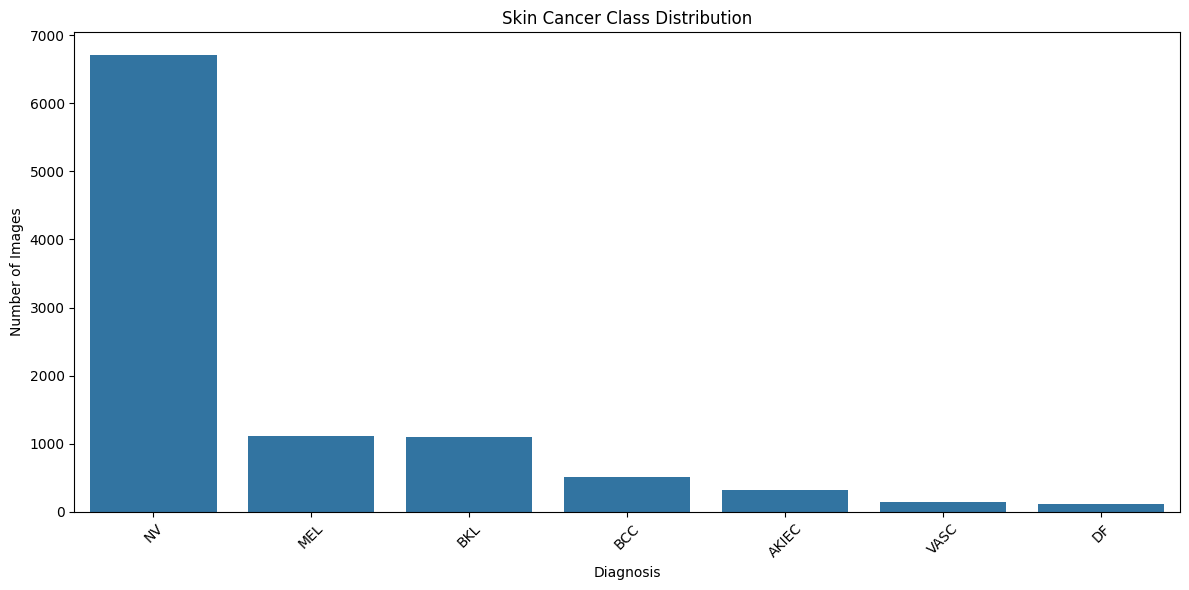

In [35]:
# plot class distribution
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title("Skin Cancer Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
# remove invalid labels if necessary
df = df[df["label"].notna()].copy()

df.reset_index(drop=True, inplace=True)

print("Final dataset size:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Final dataset size: 10015

Class distribution:
label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


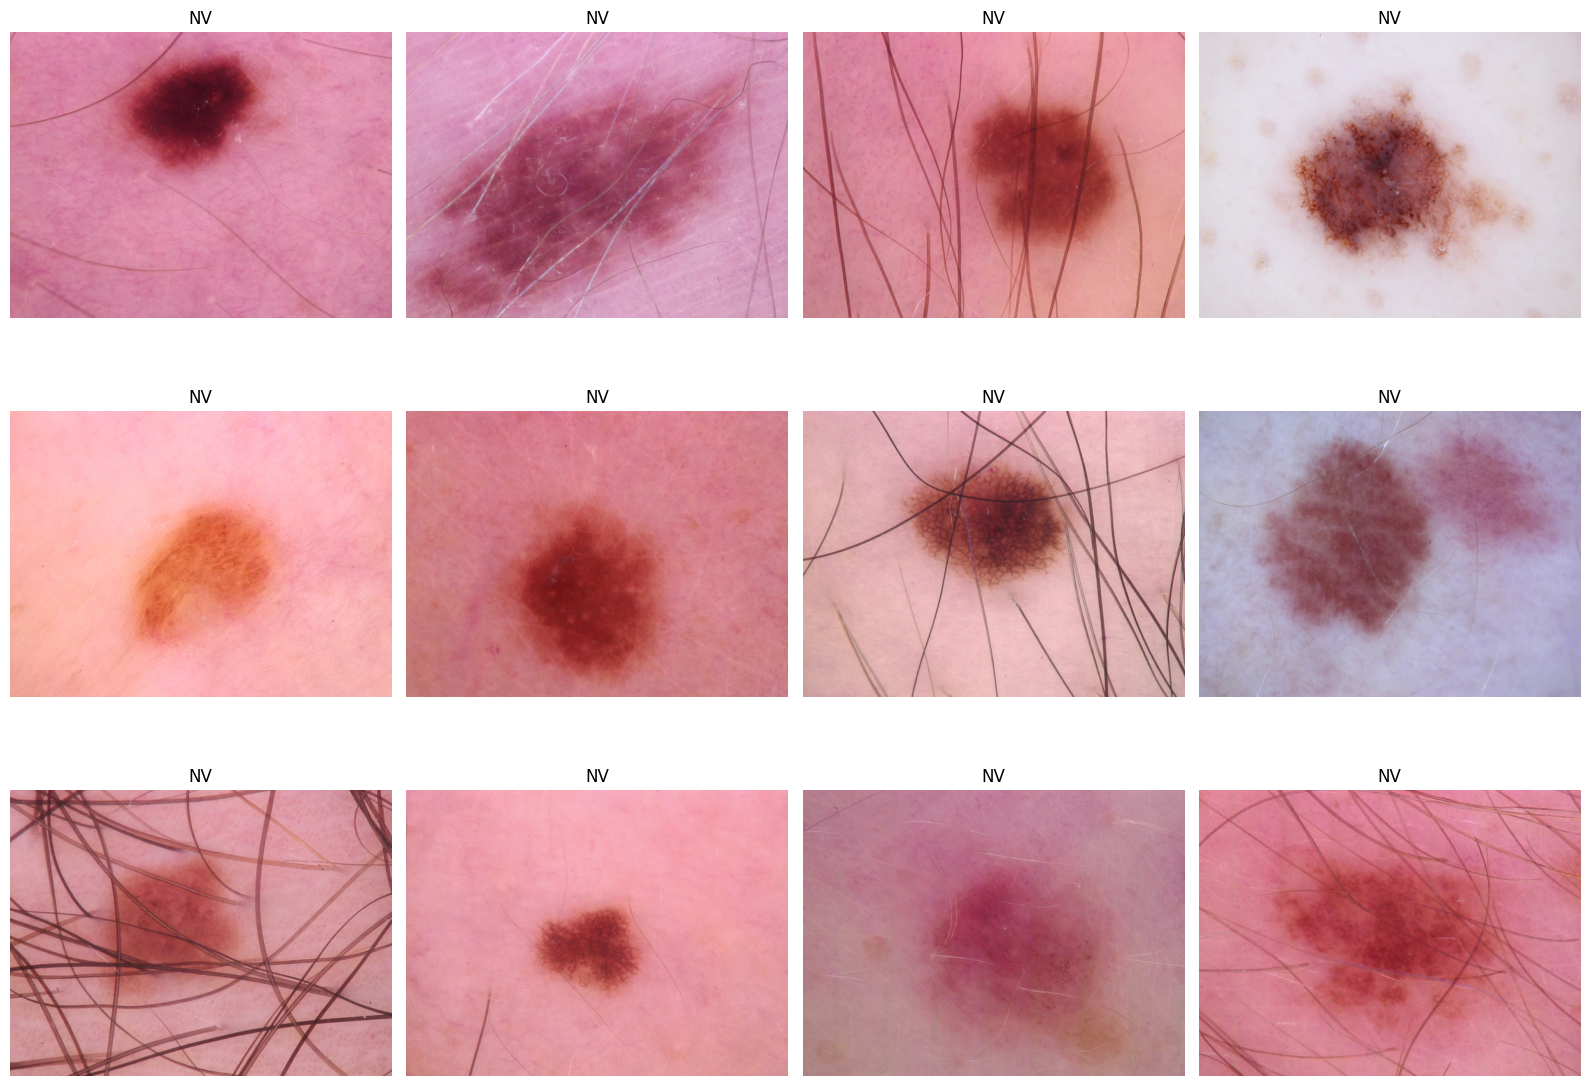

In [37]:
# visualize random images
sample_df = df.sample(
    min(12, len(df)),
    random_state=SEED
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    
    try:
        img = Image.open(row["image_path"]).convert("RGB")
        
        ax.imshow(img)
        ax.set_title(row["label"])
        ax.axis("off")
        
    except Exception as e:
        ax.set_title("Error")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
# check image sizes
sizes = []

for path in df["image_path"].sample(
    min(1000, len(df)),
    random_state=SEED
):
    try:
        with Image.open(path) as img:
            sizes.append(img.size)
    except:
        pass

size_df = pd.DataFrame(sizes, columns=["width", "height"])

print(size_df.describe())

print("\nMost common sizes:")
print(size_df.value_counts().head(20))

        width  height
count  1000.0  1000.0
mean    600.0   450.0
std       0.0     0.0
min     600.0   450.0
25%     600.0   450.0
50%     600.0   450.0
75%     600.0   450.0
max     600.0   450.0

Most common sizes:
width  height
600    450       1000
Name: count, dtype: int64


In [39]:
# remove corrupted images
valid_paths = []
invalid_paths = []

print("Checking images...")

for path in df["image_path"]:
    try:
        with Image.open(path) as img:
            img.verify()
        valid_paths.append(path)
    except:
        invalid_paths.append(path)

print("Valid images:", len(valid_paths))
print("Invalid images:", len(invalid_paths))

if invalid_paths:
    print("\nInvalid files:")
    for path in invalid_paths[:20]:
        print(path)

Checking images...
Valid images: 10015
Invalid images: 0


In [40]:
# keep only valid images
valid_path_set = set(valid_paths)

df = df[df["image_path"].isin(valid_path_set)].copy()

df.reset_index(drop=True, inplace=True)

print("Dataset after corruption check:", len(df))

Dataset after corruption check: 10015


In [41]:
# train/validation/test split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7010
Validation: 1502
Test: 1503


In [42]:
print("TRAIN")
print(train_df["label"].value_counts(normalize=True))

print("\nVALIDATION")
print(val_df["label"].value_counts(normalize=True))

print("\nTEST")
print(test_df["label"].value_counts(normalize=True))

TRAIN
label
NV       0.669472
MEL      0.111127
BKL      0.109700
BCC      0.051355
AKIEC    0.032668
VASC     0.014123
DF       0.011555
Name: proportion, dtype: float64

VALIDATION
label
NV       0.669774
MEL      0.111185
BKL      0.109854
BCC      0.051265
AKIEC    0.032623
VASC     0.013981
DF       0.011318
Name: proportion, dtype: float64

TEST
label
NV       0.669328
MEL      0.111111
BKL      0.109780
BCC      0.051231
AKIEC    0.032601
VASC     0.014637
DF       0.011311
Name: proportion, dtype: float64


In [43]:
# encode labels
label_encoder = LabelEncoder()

label_encoder.fit(df["label"])

train_df["label_id"] = label_encoder.transform(train_df["label"])
val_df["label_id"] = label_encoder.transform(val_df["label"])
test_df["label_id"] = label_encoder.transform(test_df["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)

print("\nNumber of classes:", num_classes)

Classes:
0 -> AKIEC
1 -> BCC
2 -> BKL
3 -> DF
4 -> MEL
5 -> NV
6 -> VASC

Number of classes: 7


In [44]:
# save split csv
SPLIT_DIR = os.path.join(DATASET_DIR, "splits")

os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(
    os.path.join(SPLIT_DIR, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(SPLIT_DIR, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(SPLIT_DIR, "test.csv"),
    index=False
)

print("Saved splits to:")
print(SPLIT_DIR)

Saved splits to:
E:\Pyhton code\Data Sets\archive\skin cancer\splits


In [45]:
# calculate class weights
classes = np.unique(train_df["label_id"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"]
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"{class_id} ({class_names[class_id]}): {weight:.4f}"
    )

Class weights:
0 (AKIEC): 4.3731
1 (BCC): 2.7817
2 (BKL): 1.3022
3 (DF): 12.3633
4 (MEL): 1.2855
5 (NV): 0.2134
6 (VASC): 10.1154


In [46]:
# tensorflow dataset configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", num_classes)

Image size: (224, 224)
Batch size: 32
Number of classes: 7


In [47]:
# create image preprocessing function
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    
    image.set_shape([None, None, 3])
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(image, tf.float32)
    
    return image, label

In [48]:
# create augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

In [49]:
# create tensorflow dataset
def create_dataset(dataframe, shuffle=False):
    
    paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values
    
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )
    
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )
    
    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    
    dataset = dataset.batch(BATCH_SIZE)
    
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset


train_ds = create_dataset(
    train_df,
    shuffle=True
)

val_ds = create_dataset(
    val_df,
    shuffle=False
)

test_ds = create_dataset(
    test_df,
    shuffle=False
)

print("Datasets created successfully.")

Datasets created successfully.


In [50]:
# check one batch
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("\nPixel range:")
print("Min:", tf.reduce_min(images).numpy())
print("Max:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int64'>

Pixel range:
Min: 0.0
Max: 255.0


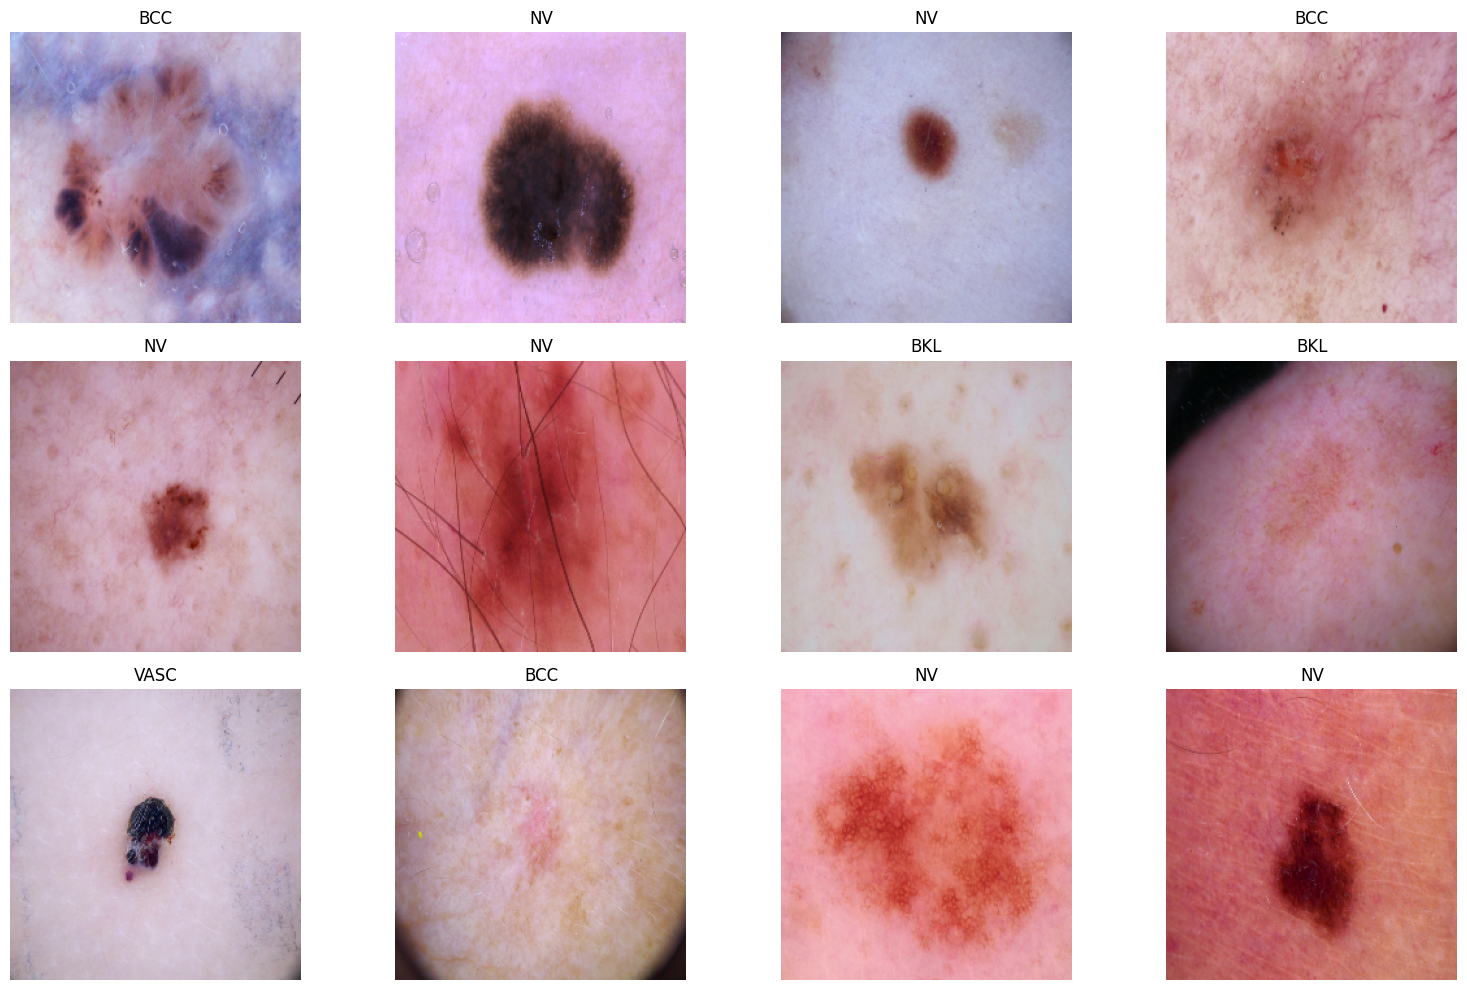

In [51]:
# visualize tensorflow batch
plt.figure(figsize=(16, 10))

for i in range(min(12, len(images))):
    
    ax = plt.subplot(3, 4, i + 1)
    
    plt.imshow(
        tf.cast(images[i], tf.uint8)
    )
    
    label_id = int(labels[i].numpy())
    
    plt.title(
        f"{class_names[label_id]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

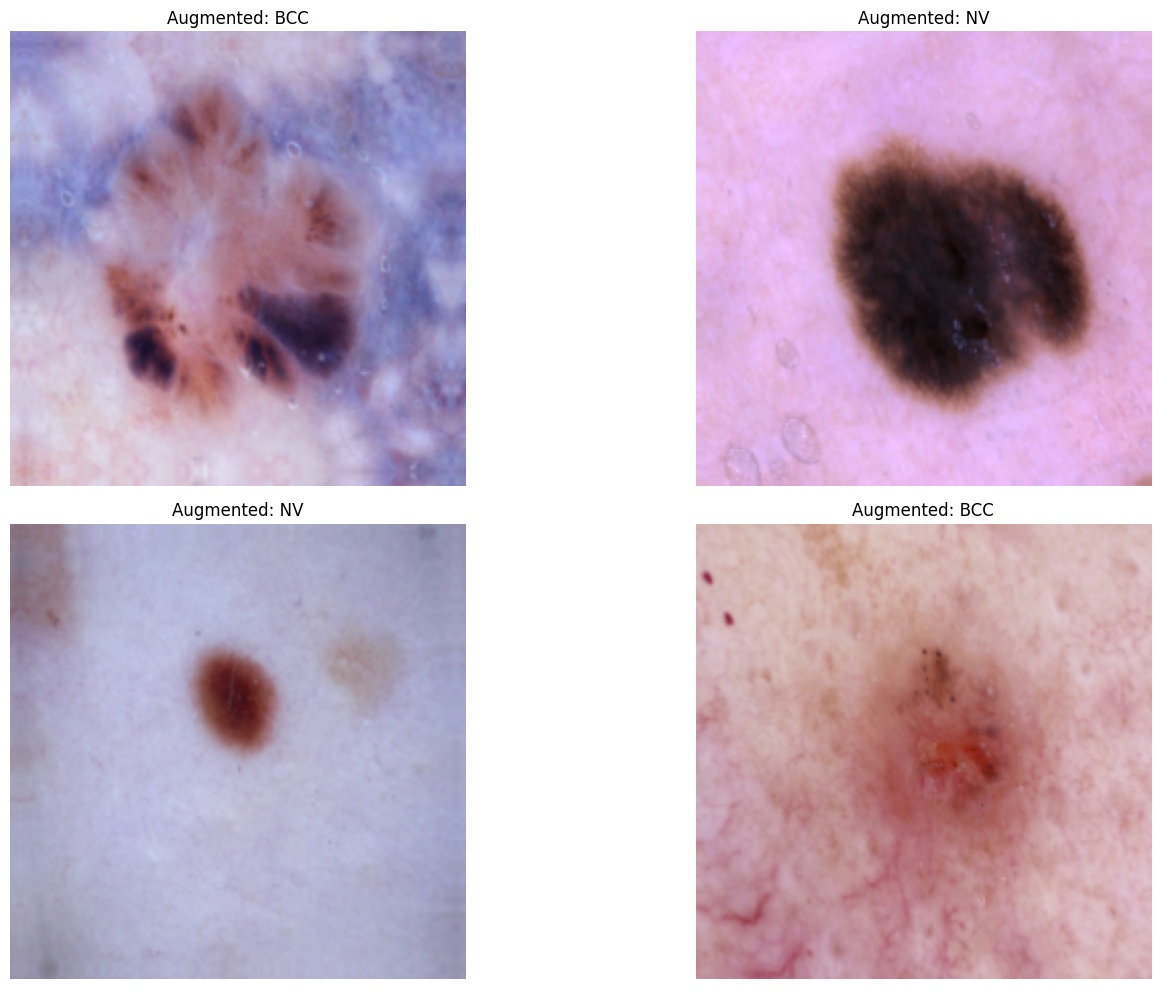

In [52]:
# test augmentation
plt.figure(figsize=(16, 10))

sample_images = images[:4]

for i in range(4):
    
    augmented = data_augmentation(
        tf.expand_dims(sample_images[i], 0),
        training=True
    )[0]
    
    ax = plt.subplot(2, 2, i + 1)
    
    plt.imshow(
        tf.cast(
            tf.clip_by_value(augmented, 0, 255),
            tf.uint8
        )
    )
    
    label_id = int(labels[i].numpy())
    
    plt.title(
        f"Augmented: {class_names[label_id]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
print("=" * 60)
print("PHASE 1 DATASET SUMMARY")
print("=" * 60)

print(f"Total images       : {len(df):,}")
print(f"Training images    : {len(train_df):,}")
print(f"Validation images  : {len(val_df):,}")
print(f"Testing images     : {len(test_df):,}")

print(f"\nNumber of classes  : {num_classes}")
print(f"Image resolution   : {IMG_SIZE}")
print(f"Batch size         : {BATCH_SIZE}")

print("\nClasses:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

print("\nClass weights:")
for class_id, weight in class_weights.items():
    print(f"  {class_names[class_id]}: {weight:.4f}")

print("\n" + "=" * 60)
print("PHASE 1 COMPLETE")
print("=" * 60)

PHASE 1 DATASET SUMMARY
Total images       : 10,015
Training images    : 7,010
Validation images  : 1,502
Testing images     : 1,503

Number of classes  : 7
Image resolution   : (224, 224)
Batch size         : 32

Classes:
  0: AKIEC
  1: BCC
  2: BKL
  3: DF
  4: MEL
  5: NV
  6: VASC

Class weights:
  AKIEC: 4.3731
  BCC: 2.7817
  BKL: 1.3022
  DF: 12.3633
  MEL: 1.2855
  NV: 0.2134
  VASC: 10.1154

PHASE 1 COMPLETE


In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [55]:
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Train samples: 7010
Validation samples: 1502
Test samples: 1503
Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Number of classes: 7
Image size: (224, 224)
Batch size: 32


In [56]:
# build efficientNetB0 model
# Clear previous models from memory
tf.keras.backend.clear_session()

# Input
inputs = keras.Input(
    shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    name="image"
)

# Data augmentation
x = data_augmentation(inputs)

# EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Pretrained backbone
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze backbone for initial training
base_model.trainable = False

# Feature extraction
x = base_model(
    x,
    training=False
)

# Global pooling
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.35)(x)

# Classification layer
outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="classifier"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="SkinCancer_EfficientNetB0"
)

model.summary()

Model: "SkinCancer_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,658 (15.50 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [57]:
# compile model
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    
    loss=keras.losses.SparseCategoricalCrossentropy(),
    
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [58]:
# create callbacks
MODEL_DIR = os.path.join(
    DATASET_DIR,
    "trained_models"
)

os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint_path = os.path.join(
    MODEL_DIR,
    "efficientnetb0_best.keras"
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Checkpoint:", checkpoint_path)

Checkpoint: E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_best.keras


In [59]:
# train frozen backbone
INITIAL_EPOCHS = 10

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.2708 - loss: 2.4364
Epoch 1: val_accuracy improved from None to 0.59654, saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_best.keras

Epoch 1: finished saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 169s 694ms/step - accuracy: 0.3485 - loss: 1.9970 - val_accuracy: 0.5965 - val_loss: 1.2087 - learning_rate: 0.0010
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.4660 - loss: 1.4633
Epoch 2: val_accuracy did not improve from 0.59654
220/220 ━━━━━━━━━━━━━━━━━━━━ 146s 662ms/step - accuracy: 0.4906 - loss: 1.4524 - val_accuracy: 0.5313 - val_loss: 1.2729 - learning_rate: 0.0010
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.5273 - loss: 1.2970
Epoch 3: val_accuracy did not improve from 0.59654
220/220 ━━━━━━━━━━━━━━━━━━━━ 145s 655ms/step - accuracy: 0.5320 - lo

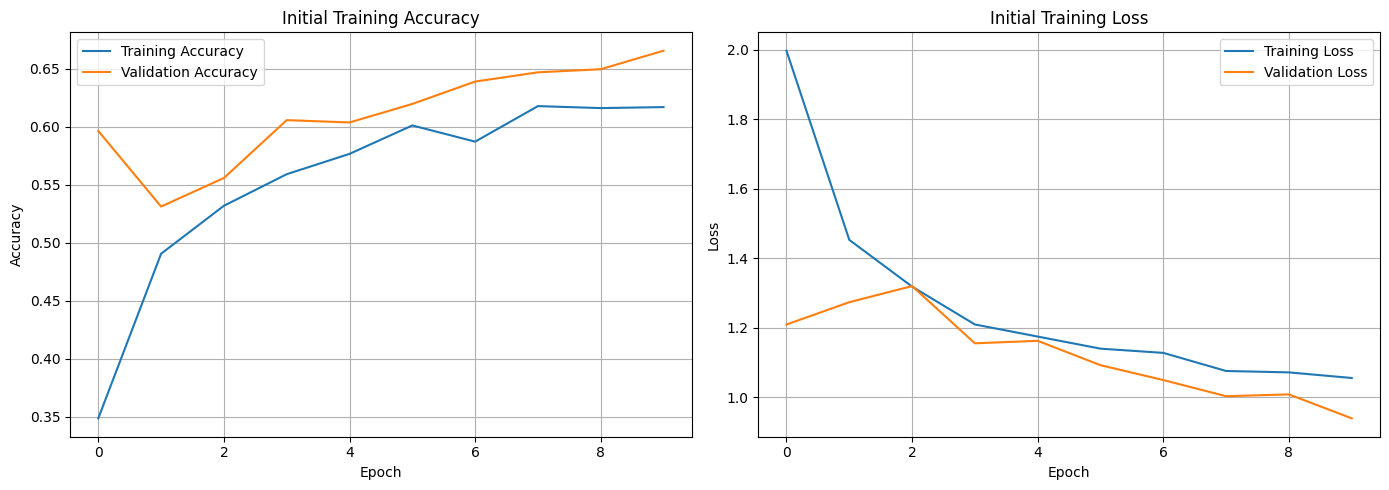

In [60]:
# plot initial training
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_initial.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_initial.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(
    history_initial.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_initial.history["val_loss"],
    label="Validation Loss"
)

plt.title("Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [61]:
# check validation performers
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print("\nInitial validation accuracy:")
print(f"{val_accuracy * 100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 480ms/step - accuracy: 0.6658 - loss: 0.9386

Initial validation accuracy:
66.58%


In [62]:
# unfreeze upper efficient layers
base_model.trainable = True

# Freeze the majority of the backbone
fine_tune_from = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

print(
    "Total backbone layers:",
    len(base_model.layers)
)

print(
    "Fine-tuning from layer:",
    fine_tune_from
)

print(
    "Trainable backbone layers:",
    sum(
        layer.trainable
        for layer in base_model.layers
    )
)

Total backbone layers: 238
Fine-tuning from layer: 166
Trainable backbone layers: 72


In [63]:
# keep batchNorm layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Trainable layers after BatchNorm freezing:",
    sum(
        layer.trainable
        for layer in model.layers
    )
)

Trainable layers after BatchNorm freezing: 7


In [64]:
# recompile with low learning rate
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    
    loss=keras.losses.SparseCategoricalCrossentropy(),
    
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [65]:
# fine-tuning callbacks
fine_tune_checkpoint = os.path.join(
    MODEL_DIR,
    "efficientnetb0_finetuned_best.keras"
)

fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=fine_tune_checkpoint,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print(
    "Fine-tuning checkpoint:",
    fine_tune_checkpoint
)

Fine-tuning checkpoint: E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_finetuned_best.keras


In [66]:
# fine-tune model
FINE_TUNE_EPOCHS = 20

initial_epoch = len(
    history_initial.history["loss"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch + FINE_TUNE_EPOCHS,
    initial_epoch=initial_epoch,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Epoch 11/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6309 - loss: 0.9072
Epoch 11: val_accuracy improved from None to 0.66844, saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_finetuned_best.keras

Epoch 11: finished saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_finetuned_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 201s 830ms/step - accuracy: 0.6359 - loss: 0.9263 - val_accuracy: 0.6684 - val_loss: 0.9148 - learning_rate: 1.0000e-05
Epoch 12/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.6376 - loss: 0.9150
Epoch 12: val_accuracy improved from 0.66844 to 0.67643, saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_finetuned_best.keras

Epoch 12: finished saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\efficientnetb0_finetuned_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 180s 816ms/step - accuracy: 0.6466 - loss: 0.

In [67]:
# combine training histories
acc = (
    history_initial.history["accuracy"]
    + history_finetune.history["accuracy"]
)

val_acc = (
    history_initial.history["val_accuracy"]
    + history_finetune.history["val_accuracy"]
)

loss = (
    history_initial.history["loss"]
    + history_finetune.history["loss"]
)

val_loss = (
    history_initial.history["val_loss"]
    + history_finetune.history["val_loss"]
)

epochs_range = range(1, len(acc) + 1)

print("Total epochs trained:", len(acc))

Total epochs trained: 20


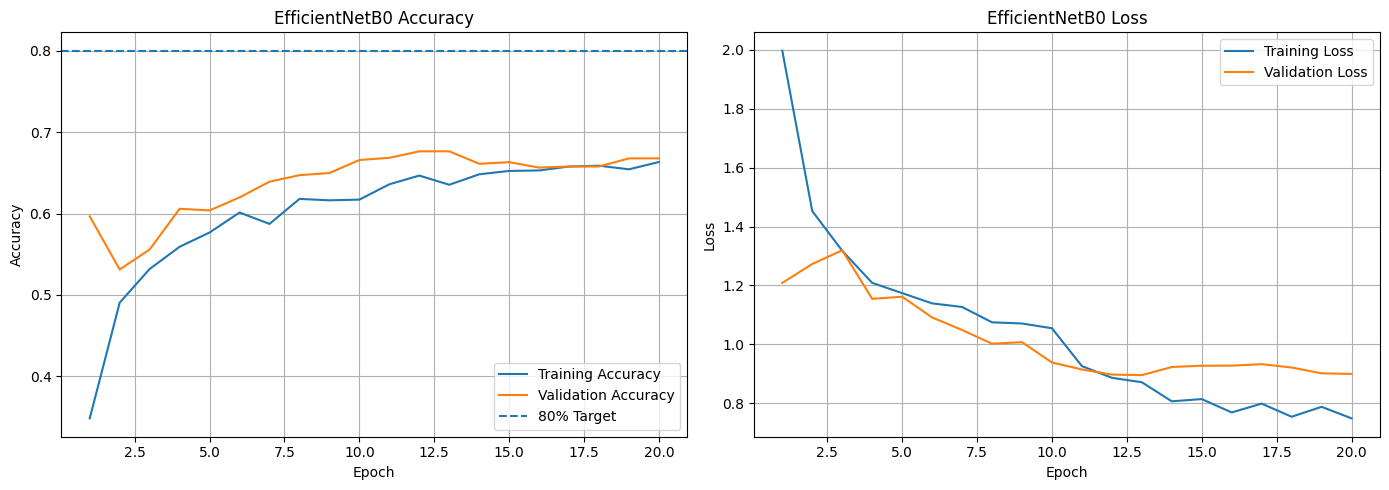

In [68]:
# plot complete training
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    acc,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy"
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% Target"
)

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [69]:
# find best validation accuracy
best_epoch = np.argmax(val_acc) + 1
best_val_accuracy = max(val_acc)

print("=" * 60)
print("BEST VALIDATION PERFORMANCE")
print("=" * 60)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

if best_val_accuracy >= 0.80:
    print("\n✅ 80%+ validation accuracy achieved!")
else:
    print("\n⚠️ Validation accuracy is below 80%.")
    print("We will evaluate the model before deciding what to improve.")

print("=" * 60)

BEST VALIDATION PERFORMANCE
Best epoch: 12
Best validation accuracy: 67.64%

⚠️ Validation accuracy is below 80%.
We will evaluate the model before deciding what to improve.


In [70]:
# load best fine-tuned model
if os.path.exists(fine_tune_checkpoint):
    
    model = keras.models.load_model(
        fine_tune_checkpoint
    )
    
    print("Best fine-tuned model loaded.")
    
else:
    print(
        "Fine-tuned checkpoint not found."
    )

Best fine-tuned model loaded.


In [71]:
# validation ealuation
val_results = model.evaluate(
    val_ds,
    verbose=1
)

print("\nValidation Results")
print("=" * 40)
print(f"Loss     : {val_results[0]:.4f}")
print(f"Accuracy : {val_results[1] * 100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 478ms/step - accuracy: 0.6764 - loss: 0.8975

Validation Results
Loss     : 0.8975
Accuracy : 67.64%


In [72]:
# generate test predictions
print("Generating test predictions...")

y_true = test_df["label_id"].values

y_probability = model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions generated.")

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_probability.shape)

Generating test predictions...
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 556ms/step
Predictions generated.
True labels: (1503,)
Predictions: (1503,)
Probabilities: (1503, 7)


In [73]:
# test accuracy
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {test_precision * 100:.2f}%")
print(f"Recall    : {test_recall * 100:.2f}%")
print(f"F1 Score  : {test_f1 * 100:.2f}%")

print("=" * 60)

TEST SET PERFORMANCE
Accuracy  : 68.66%
Precision : 78.09%
Recall    : 68.66%
F1 Score  : 71.21%


In [74]:
# classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       AKIEC     0.7059    0.2449    0.3636        49
         BCC     0.5281    0.6104    0.5663        77
         BKL     0.4403    0.6485    0.5245       165
          DF     0.2195    0.5294    0.3103        17
         MEL     0.3483    0.6048    0.4420       167
          NV     0.9483    0.7296    0.8247      1006
        VASC     0.4490    1.0000    0.6197        22

    accuracy                         0.6866      1503
   macro avg     0.5199    0.6239    0.5216      1503
weighted avg     0.7809    0.6866    0.7121      1503



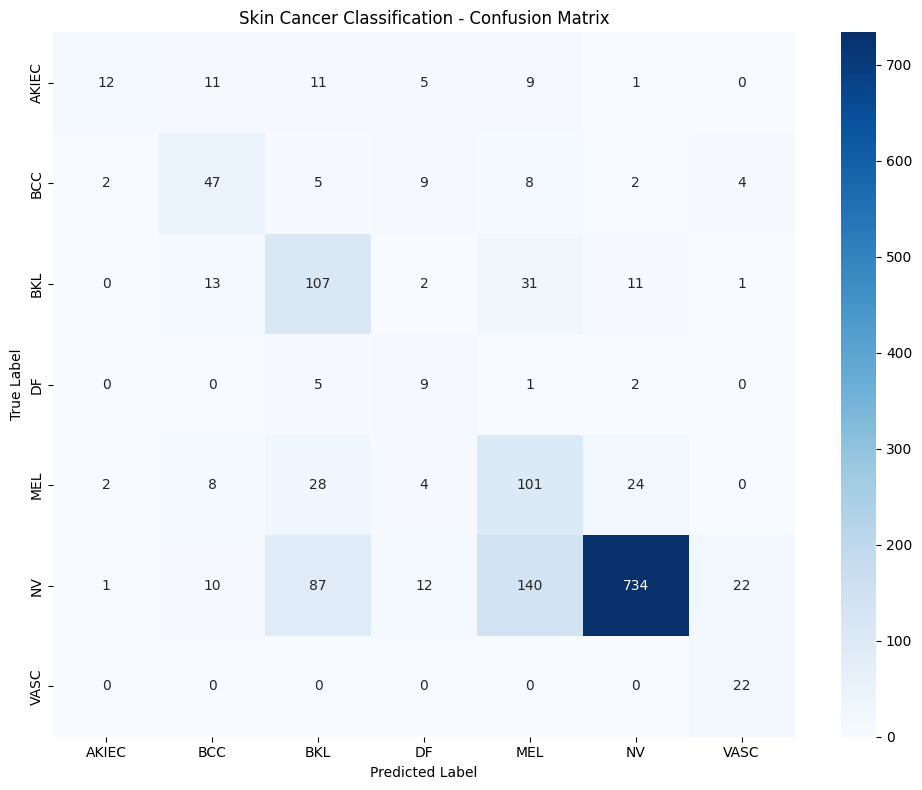

In [75]:
# confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Skin Cancer Classification - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

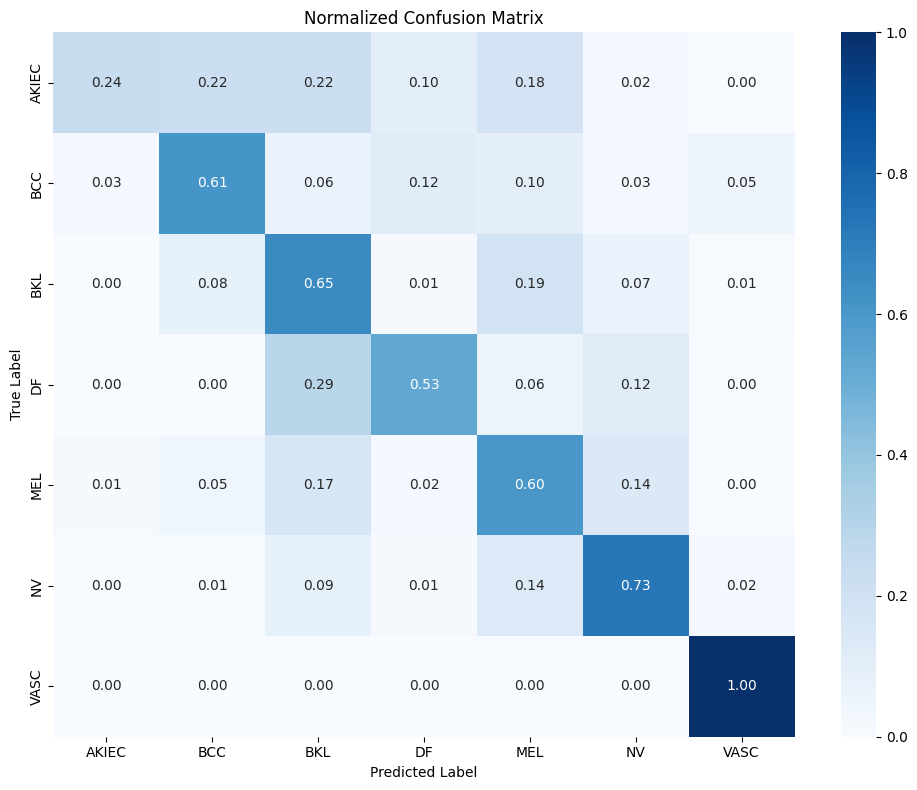

In [76]:
#normalized confusion matrix
cm_normalized = (
    cm.astype("float")
    / cm.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [77]:
# per-class accuracy/recall
class_recall = recall_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

class_precision = precision_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

class_f1 = f1_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

performance_df = pd.DataFrame({
    "Class": class_names,
    "Precision": class_precision,
    "Recall": class_recall,
    "F1 Score": class_f1
})

performance_df["Precision"] *= 100
performance_df["Recall"] *= 100
performance_df["F1 Score"] *= 100

display(
    performance_df.round(2)
)

,Class,Precision,Recall,F1 Score
0,AKIEC,70.59,24.49,36.36
1,BCC,52.81,61.04,56.63
2,BKL,44.03,64.85,52.45
3,DF,21.95,52.94,31.03
4,MEL,34.83,60.48,44.20
5,NV,94.83,72.96,82.47
6,VASC,44.90,100.00,61.97


In [78]:
# save final model
FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "skin_cancer_efficientnetb0_final.keras"
)

model.save(
    FINAL_MODEL_PATH
)

print("Final model saved:")
print(FINAL_MODEL_PATH)

Final model saved:
E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\skin_cancer_efficientnetb0_final.keras


In [79]:
CLASS_NAMES_PATH = os.path.join(
    MODEL_DIR,
    "class_names.txt"
)

with open(
    CLASS_NAMES_PATH,
    "w"
) as f:
    
    for class_name in class_names:
        f.write(class_name + "\n")

print("Class names saved:")
print(CLASS_NAMES_PATH)

Class names saved:
E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\class_names.txt


In [80]:
#create prediction function
def predict_skin_lesion(
    image_path,
    model=model
):
    
    # Load image
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    
    image.set_shape([None, None, 3])
    
    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    # Convert to batch
    image_batch = tf.expand_dims(
        image,
        axis=0
    )
    
    # Prediction
    probabilities = model.predict(
        image_batch,
        verbose=0
    )[0]
    
    predicted_id = np.argmax(
        probabilities
    )
    
    predicted_class = class_names[
        predicted_id
    ]
    
    confidence = probabilities[
        predicted_id
    ]
    
    return (
        predicted_class,
        confidence,
        probabilities
    )

In [81]:
#test prediction function
test_image_path = test_df.iloc[0]["image_path"]

predicted_class, confidence, probabilities = predict_skin_lesion(
    test_image_path
)

actual_class = test_df.iloc[0]["label"]

print("Image:", test_image_path)
print("Actual:", actual_class)
print("Predicted:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

print("\nClass probabilities:")

for class_name, probability in zip(
    class_names,
    probabilities
):
    print(
        f"{class_name:8s}: "
        f"{probability * 100:.2f}%"
    )

Image: E:\Pyhton code\Data Sets\archive\skin cancer\images\ISIC_0029202.jpg
Actual: BKL
Predicted: BKL
Confidence: 80.96%

Class probabilities:
AKIEC   : 0.00%
BCC     : 0.01%
BKL     : 80.96%
DF      : 0.12%
MEL     : 7.45%
NV      : 8.03%
VASC    : 3.42%


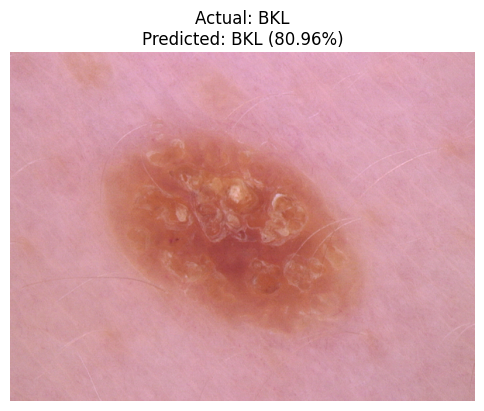

In [82]:
#visualize prediction
image = Image.open(
    test_image_path
).convert("RGB")

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class} "
    f"({confidence * 100:.2f}%)"
)

plt.axis("off")
plt.show()

In [83]:
#summary
print("=" * 70)
print("PHASE 2 COMPLETE")
print("=" * 70)

print(f"Model              : EfficientNetB0")
print(f"Classes            : {num_classes}")
print(f"Training images    : {len(train_df):,}")
print(f"Validation images  : {len(val_df):,}")
print(f"Test images        : {len(test_df):,}")

print("\nPerformance")
print("-" * 40)

print(
    f"Best Val Accuracy  : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Test Accuracy      : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Precision     : "
    f"{test_precision * 100:.2f}%"
)

print(
    f"Test Recall        : "
    f"{test_recall * 100:.2f}%"
)

print(
    f"Test F1            : "
    f"{test_f1 * 100:.2f}%"
)

print("\nModel:")
print(FINAL_MODEL_PATH)

print("=" * 70)

PHASE 2 COMPLETE
Model              : EfficientNetB0
Classes            : 7
Training images    : 7,010
Validation images  : 1,502
Test images        : 1,503

Performance
----------------------------------------
Best Val Accuracy  : 67.64%
Test Accuracy      : 68.66%
Test Precision     : 78.09%
Test Recall        : 68.66%
Test F1            : 71.21%

Model:
E:\Pyhton code\Data Sets\archive\skin cancer\trained_models\skin_cancer_efficientnetb0_final.keras


In [92]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Clear old model from memory
tf.keras.backend.clear_session()
gc.collect()

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Improved resolution
IMG_SIZE = (260, 260)

# Slightly smaller batch to accommodate larger images
BATCH_SIZE = 24

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

TensorFlow: 2.20.0
GPU: []
Image size: (260, 260)
Batch size: 24


In [93]:
data_augmentation_v2 = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal_and_vertical"
        ),

        layers.RandomRotation(
            0.12
        ),

        layers.RandomZoom(
            height_factor=(-0.10, 0.15),
            width_factor=(-0.10, 0.15)
        ),

        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),

        layers.RandomContrast(
            0.15
        ),
    ],
    name="medical_augmentation"
)

print("Augmentation pipeline created.")

Augmentation pipeline created.


In [94]:
def load_image_v2(image_path, label):
    
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    
    image.set_shape([None, None, 3])
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(
        image,
        tf.float32
    )
    
    return image, label


def create_dataset_v2(
    dataframe,
    shuffle=False
):
    
    paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values
    
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )
    
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )
    
    dataset = dataset.map(
        load_image_v2,
        num_parallel_calls=AUTOTUNE
    )
    
    dataset = dataset.batch(
        BATCH_SIZE
    )
    
    dataset = dataset.prefetch(
        AUTOTUNE
    )
    
    return dataset


train_ds_v2 = create_dataset_v2(
    train_df,
    shuffle=True
)

val_ds_v2 = create_dataset_v2(
    val_df,
    shuffle=False
)

test_ds_v2 = create_dataset_v2(
    test_df,
    shuffle=False
)

print("New datasets created.")

New datasets created.


In [95]:
images_v2, labels_v2 = next(
    iter(train_ds_v2)
)

print("Images:", images_v2.shape)
print("Labels:", labels_v2.shape)

print(
    "Pixel range:",
    float(tf.reduce_min(images_v2)),
    "to",
    float(tf.reduce_max(images_v2))
)

Images: (24, 260, 260, 3)
Labels: (24,)
Pixel range: 0.0 to 255.0


In [96]:
inputs = keras.Input(
    shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    name="image"
)

# Augmentation
x = data_augmentation_v2(inputs)

# EfficientNet preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(
    x
)

# EfficientNetB2 backbone
base_model_v2 = tf.keras.applications.EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

# Initially freeze backbone
base_model_v2.trainable = False

x = base_model_v2(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(
    0.40
)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="classifier"
)(x)

model_v2 = keras.Model(
    inputs,
    outputs,
    name="SkinCancer_EfficientNetB2"
)

model_v2.summary()

Model: "SkinCancer_EfficientNetB2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ medical_augmentation            │ (None, 260, 260, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 7)              │         9,863 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,784,064 (29.69 MB)

 Trainable params: 12,679 (49.53 KB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [98]:
model_v2.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    
    loss=keras.losses.SparseCategoricalCrossentropy(),
    
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [99]:
MODEL_DIR_V2 = os.path.join(
    DATASET_DIR,
    "trained_models_v2"
)

os.makedirs(
    MODEL_DIR_V2,
    exist_ok=True
)

checkpoint_v2 = os.path.join(
    MODEL_DIR_V2,
    "efficientnetb2_best.keras"
)

callbacks_v2 = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_v2,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print(checkpoint_v2)

E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_best.keras


In [100]:
history_v2_initial = model_v2.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks_v2,
    verbose=1
)

Epoch 1/12
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1944 - loss: 2.8582
Epoch 1: val_accuracy improved from None to 0.38748, saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_best.keras

Epoch 1: finished saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_best.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 408s 1s/step - accuracy: 0.2478 - loss: 2.4048 - val_accuracy: 0.3875 - val_loss: 1.7394 - learning_rate: 3.0000e-04
Epoch 2/12
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.3355 - loss: 1.7189
Epoch 2: val_accuracy improved from 0.38748 to 0.40280, saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_best.keras

Epoch 2: finished saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_best.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.3479 - loss: 1.7843 - val_accuracy: 0.4028 - val_loss: 1.8

In [101]:
best_initial_v2 = max(
    history_v2_initial.history["val_accuracy"]
)

print(
    f"Best frozen-backbone "
    f"validation accuracy: "
    f"{best_initial_v2 * 100:.2f}%"
)

Best frozen-backbone validation accuracy: 58.66%


In [102]:
base_model_v2.trainable = True

fine_tune_from = int(
    len(base_model_v2.layers) * 0.60
)

for layer in base_model_v2.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model_v2.layers[fine_tune_from:]:
    layer.trainable = True

# Keep BatchNorm frozen
for layer in base_model_v2.layers:
    if isinstance(
        layer,
        layers.BatchNormalization
    ):
        layer.trainable = False

print(
    "Total backbone layers:",
    len(base_model_v2.layers)
)

print(
    "Fine-tuning from:",
    fine_tune_from
)

print(
    "Trainable backbone layers:",
    sum(
        layer.trainable
        for layer in base_model_v2.layers
    )
)

Total backbone layers: 340
Fine-tuning from: 204
Trainable backbone layers: 108


In [104]:
model_v2.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=5e-6
    ),
    
    loss=keras.losses.SparseCategoricalCrossentropy(),
    
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Fine-tuning model compiled successfully.")

Fine-tuning model compiled successfully.


In [105]:
checkpoint_v2_ft = os.path.join(
    MODEL_DIR_V2,
    "efficientnetb2_finetuned_best.keras"
)

callbacks_v2_ft = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_v2_ft,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [106]:
initial_epochs_v2 = len(
    history_v2_initial.history["loss"]
)

history_v2_ft = model_v2.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    initial_epoch=initial_epochs_v2,
    epochs=32,
    class_weight=class_weights,
    callbacks=callbacks_v2_ft,
    verbose=1
)

Epoch 13/32
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5593 - loss: 1.1030
Epoch 13: val_accuracy improved from None to 0.56858, saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_finetuned_best.keras

Epoch 13: finished saving model to E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\efficientnetb2_finetuned_best.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.5646 - loss: 1.1089 - val_accuracy: 0.5686 - val_loss: 1.2223 - learning_rate: 5.0000e-06
Epoch 14/32
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5639 - loss: 1.0475
Epoch 14: val_accuracy did not improve from 0.56858
293/293 ━━━━━━━━━━━━━━━━━━━━ 1108s 4s/step - accuracy: 0.5675 - loss: 1.0619 - val_accuracy: 0.5666 - val_loss: 1.2478 - learning_rate: 5.0000e-06
Epoch 15/32
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5777 - loss: 1.0208
Epoch 15: val_accuracy did not improve from 0.56858

Epoch 15: ReduceLROnPlateau reducing lea

In [107]:
acc_v2 = (
    history_v2_initial.history["accuracy"]
    +
    history_v2_ft.history["accuracy"]
)

val_acc_v2 = (
    history_v2_initial.history["val_accuracy"]
    +
    history_v2_ft.history["val_accuracy"]
)

loss_v2 = (
    history_v2_initial.history["loss"]
    +
    history_v2_ft.history["loss"]
)

val_loss_v2 = (
    history_v2_initial.history["val_loss"]
    +
    history_v2_ft.history["val_loss"]
)

print(
    "Total epochs:",
    len(acc_v2)
)

Total epochs: 32


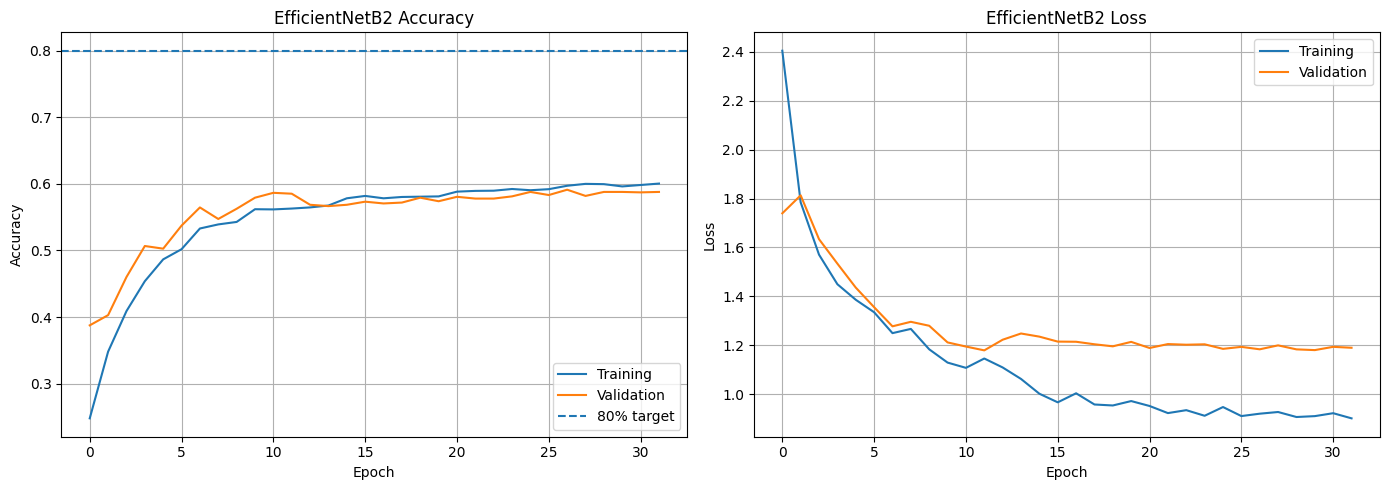

In [108]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    acc_v2,
    label="Training"
)

plt.plot(
    val_acc_v2,
    label="Validation"
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80% target"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "EfficientNetB2 Accuracy"
)

plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(
    loss_v2,
    label="Training"
)

plt.plot(
    val_loss_v2,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "EfficientNetB2 Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [109]:
best_epoch_v2 = (
    np.argmax(val_acc_v2) + 1
)

best_val_v2 = max(val_acc_v2)

print("=" * 60)
print("EFFICIENTNETB2 RESULT")
print("=" * 60)

print(
    "Best epoch:",
    best_epoch_v2
)

print(
    f"Best validation accuracy: "
    f"{best_val_v2 * 100:.2f}%"
)

print("=" * 60)

EFFICIENTNETB2 RESULT
Best epoch: 27
Best validation accuracy: 59.12%


In [110]:
if os.path.exists(checkpoint_v2_ft):
    
    model_v2 = keras.models.load_model(
        checkpoint_v2_ft
    )
    
    print(
        "Best fine-tuned B2 model loaded."
    )

else:
    
    model_v2 = keras.models.load_model(
        checkpoint_v2
    )
    
    print(
        "Best frozen-backbone B2 model loaded."
    )

Best fine-tuned B2 model loaded.


In [111]:
val_results_v2 = model_v2.evaluate(
    val_ds_v2,
    verbose=1
)

print(
    f"\nValidation accuracy: "
    f"{val_results_v2[1] * 100:.2f}%"
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 777ms/step - accuracy: 0.5912 - loss: 1.1831

Validation accuracy: 59.12%


In [112]:
print("Generating test predictions...")

y_true_v2 = test_df[
    "label_id"
].values

y_probability_v2 = model_v2.predict(
    test_ds_v2,
    verbose=1
)

y_pred_v2 = np.argmax(
    y_probability_v2,
    axis=1
)

print(
    "Predictions:",
    len(y_pred_v2)
)

Generating test predictions...
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 925ms/step
Predictions: 1503


In [113]:
test_accuracy_v2 = accuracy_score(
    y_true_v2,
    y_pred_v2
)

test_precision_v2 = precision_score(
    y_true_v2,
    y_pred_v2,
    average="weighted",
    zero_division=0
)

test_recall_v2 = recall_score(
    y_true_v2,
    y_pred_v2,
    average="weighted",
    zero_division=0
)

test_f1_v2 = f1_score(
    y_true_v2,
    y_pred_v2,
    average="weighted",
    zero_division=0
)

test_f1_macro_v2 = f1_score(
    y_true_v2,
    y_pred_v2,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("EFFICIENTNETB2 TEST RESULT")
print("=" * 60)

print(
    f"Accuracy        : "
    f"{test_accuracy_v2 * 100:.2f}%"
)

print(
    f"Weighted F1     : "
    f"{test_f1_v2 * 100:.2f}%"
)

print(
    f"Macro F1        : "
    f"{test_f1_macro_v2 * 100:.2f}%"
)

print(
    f"Precision       : "
    f"{test_precision_v2 * 100:.2f}%"
)

print(
    f"Recall          : "
    f"{test_recall_v2 * 100:.2f}%"
)

print("=" * 60)

EFFICIENTNETB2 TEST RESULT
Accuracy        : 58.68%
Weighted F1     : 63.11%
Macro F1        : 45.70%
Precision       : 76.45%
Recall          : 58.68%


In [114]:
print(
    classification_report(
        y_true_v2,
        y_pred_v2,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       AKIEC     0.4348    0.4082    0.4211        49
         BCC     0.4454    0.6883    0.5408        77
         BKL     0.3976    0.6000    0.4783       165
          DF     0.1512    0.7647    0.2524        17
         MEL     0.2781    0.5329    0.3655       167
          NV     0.9671    0.5845    0.7286      1006
        VASC     0.2667    0.9091    0.4124        22

    accuracy                         0.5868      1503
   macro avg     0.4201    0.6411    0.4570      1503
weighted avg     0.7645    0.5868    0.6311      1503



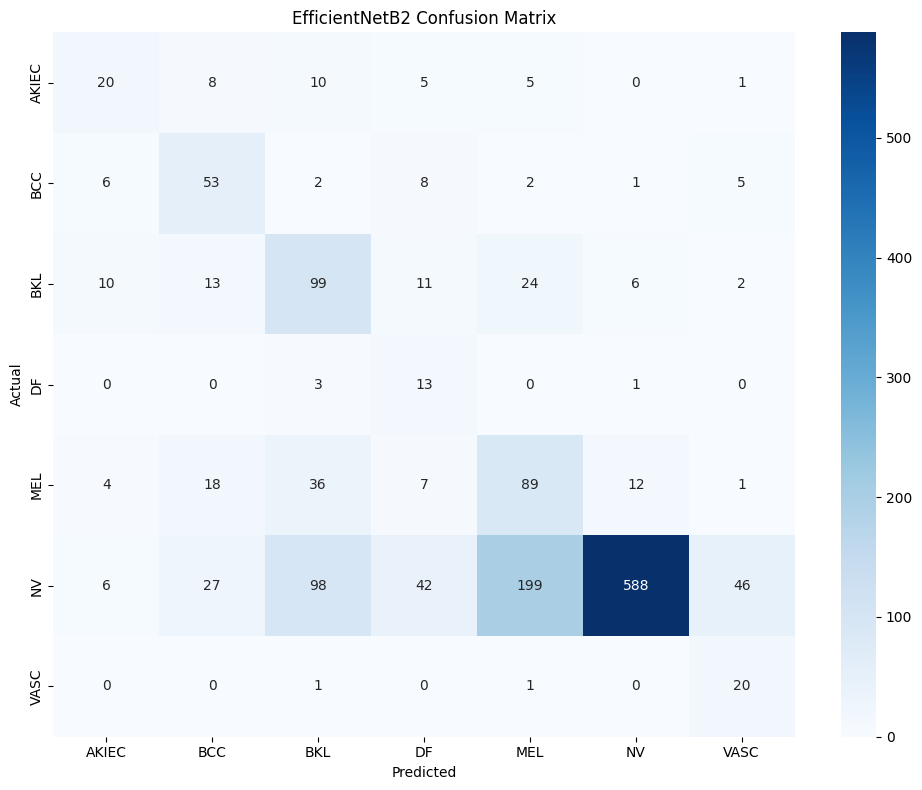

In [115]:
cm_v2 = confusion_matrix(
    y_true_v2,
    y_pred_v2
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "EfficientNetB2 Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()

In [116]:
precision_per_class = precision_score(
    y_true_v2,
    y_pred_v2,
    average=None,
    zero_division=0
)

recall_per_class = recall_score(
    y_true_v2,
    y_pred_v2,
    average=None,
    zero_division=0
)

f1_per_class = f1_score(
    y_true_v2,
    y_pred_v2,
    average=None,
    zero_division=0
)

class_results_v2 = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class * 100,
    "Recall": recall_per_class * 100,
    "F1": f1_per_class * 100
})

display(
    class_results_v2.round(2)
)

,Class,Precision,Recall,F1
0,AKIEC,43.48,40.82,42.11
1,BCC,44.54,68.83,54.08
2,BKL,39.76,60.00,47.83
3,DF,15.12,76.47,25.24
4,MEL,27.81,53.29,36.55
5,NV,96.71,58.45,72.86
6,VASC,26.67,90.91,41.24


In [117]:
FINAL_MODEL_V2 = os.path.join(
    MODEL_DIR_V2,
    "skin_cancer_efficientnetb2_final.keras"
)

model_v2.save(
    FINAL_MODEL_V2
)

print(
    "Saved:",
    FINAL_MODEL_V2
)

Saved: E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\skin_cancer_efficientnetb2_final.keras


In [118]:
comparison = pd.DataFrame({
    "Model": [
        "EfficientNetB0",
        "EfficientNetB2"
    ],
    
    "Validation Accuracy": [
        best_val_accuracy * 100,
        best_val_v2 * 100
    ],
    
    "Test Accuracy": [
        test_accuracy * 100,
        test_accuracy_v2 * 100
    ],
    
    "Weighted F1": [
        test_f1 * 100,
        test_f1_v2 * 100
    ],
    
    "Macro F1": [
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ) * 100,
        
        test_f1_macro_v2 * 100
    ]
})

display(
    comparison.round(2)
)

,Model,Validation Accuracy,Test Accuracy,Weighted F1,Macro F1
0,EfficientNetB0,67.64,68.66,71.21,52.16
1,EfficientNetB2,59.12,58.68,63.11,45.70


In [119]:
print("=" * 70)
print("PHASE 2B COMPLETE")
print("=" * 70)

print("\nEfficientNetB0")
print(
    f"Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)
print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print("\nEfficientNetB2")
print(
    f"Validation Accuracy: "
    f"{best_val_v2 * 100:.2f}%"
)
print(
    f"Test Accuracy: "
    f"{test_accuracy_v2 * 100:.2f}%"
)
print(
    f"Weighted F1: "
    f"{test_f1_v2 * 100:.2f}%"
)
print(
    f"Macro F1: "
    f"{test_f1_macro_v2 * 100:.2f}%"
)

print("\nSaved model:")
print(FINAL_MODEL_V2)

print("=" * 70)

PHASE 2B COMPLETE

EfficientNetB0
Validation Accuracy: 67.64%
Test Accuracy: 68.66%

EfficientNetB2
Validation Accuracy: 59.12%
Test Accuracy: 58.68%
Weighted F1: 63.11%
Macro F1: 45.70%

Saved model:
E:\Pyhton code\Data Sets\archive\skin cancer\trained_models_v2\skin_cancer_efficientnetb2_final.keras


In [120]:
print("=" * 70)
print("GROUND TRUTH STRUCTURE")
print("=" * 70)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nShape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nPossible patient/lesion columns:")

for col in df.columns:
    col_lower = col.lower()

    if any(
        keyword in col_lower
        for keyword in [
            "patient",
            "lesion",
            "subject",
            "case",
            "study"
        ]
    ):
        print(
            f"\n{col}:"
        )
        print(
            "Unique values:",
            df[col].nunique()
        )
        print(
            "Examples:",
            df[col].dropna().unique()[:10]
        )

GROUND TRUTH STRUCTURE

Columns:
0 : image
1 : MEL
2 : NV
3 : BCC
4 : AKIEC
5 : BKL
6 : DF
7 : VASC
8 : _image_stem
9 : image_path
10 : label

Shape:
(10015, 11)

First 5 rows:


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,_image_stem,image_path,label
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024306,E:\Pyhton code\Data Sets\archive\skin cancer\i...,NV
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024307,E:\Pyhton code\Data Sets\archive\skin cancer\i...,NV
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024308,E:\Pyhton code\Data Sets\archive\skin cancer\i...,NV
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024309,E:\Pyhton code\Data Sets\archive\skin cancer\i...,NV
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0024310,E:\Pyhton code\Data Sets\archive\skin cancer\i...,MEL



Possible patient/lesion columns:
